## Unpaired Image to Image translation model

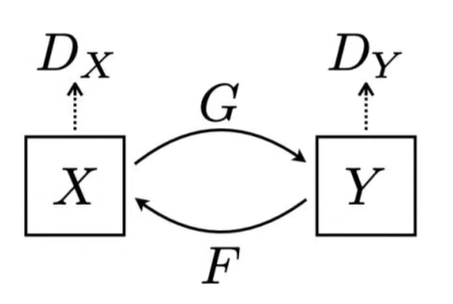

#### Here thier is the normal "GAN" based loss and below is cycle loss additionally added

#### Cycle consistency loss

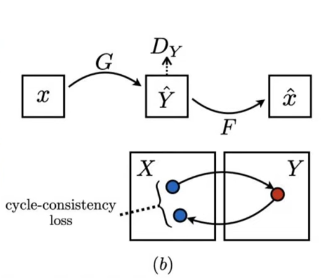

#### Here in the above "cycle consistency loss" the X (is real horse image) and X_bar (is the genrated horse image) here we calculate either pixel_wise loss or L1 loss

#### Identity Loss

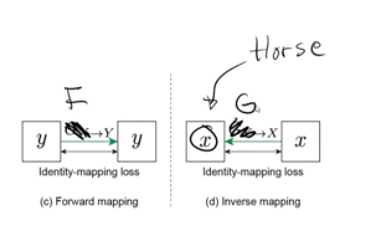

#### here this loss basically tells that IF G is used to genreate the horse and we sent the X(as horse) then it shouldn't touch the image i.e no change in any thingsof image should happend and this is calculated with L1 loss (and this is identity loss) and extra loss

### Loss summary

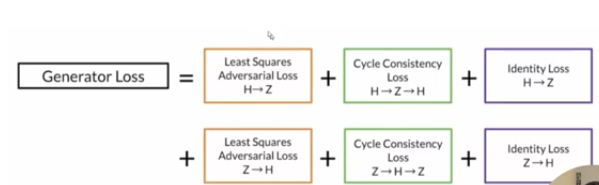

### > Yellow frame - for generator loss
### > Green frame - for cycle consistency loss
### > purpule frame - for identity loss

#### Here the first yello frame basically is the genrator with "least square loss" because we are not using BCE only least square for Horse to Zebra


> Note : Identity loss is not used for all dataset it is mostly used or painting related dataset so we can neglect it

#### Architecture overview

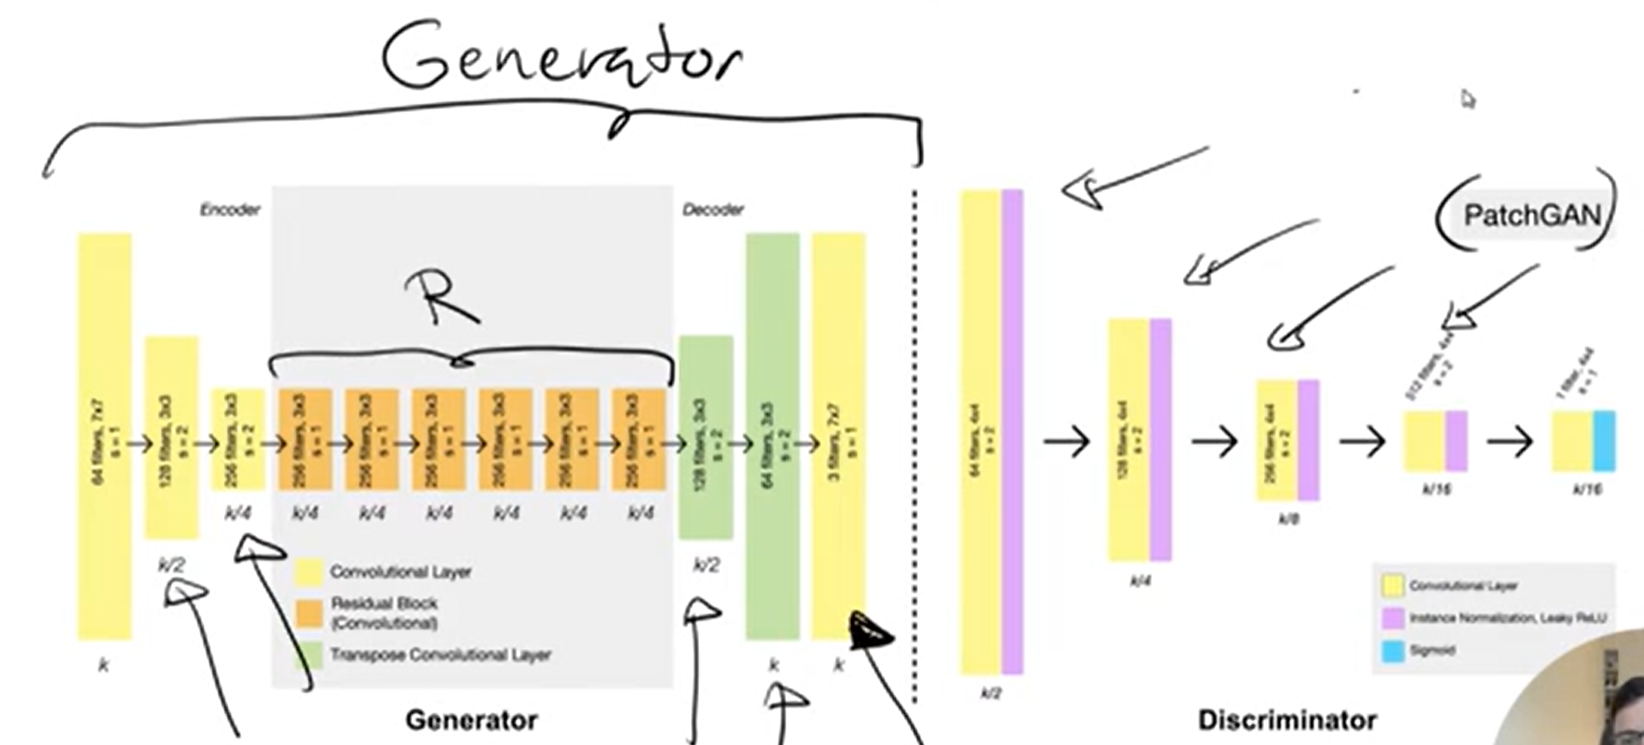

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import os

### Building discriminator block

In [ ]:
class Block(nn.Module):
  def __init__(self,in_channels,out_channels,stride):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size=4,padding=1,stride=stride,padding_mode="reflect"),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2)
    )
  def forward(self,x):
    return self.conv(x)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self,in_channels=3,features=[64,128,256,512]):
    super().__init__()
    self.initial = nn.Sequential(
        nn.Conv2d(
            in_channels,
            features[0],
            kernel_size=4,
            stride=2,
            padding=1,
            padding_mode = "reflect"
        ),
        nn.LeakyReLU(0.2)
    )
    layers = []
    in_channels = features[0]
    for feature in features[1:]:
      layers.append(Block(in_channels,feature,stride =1 if feature==features[-1] else 2 ))
      in_channels = feature
    layers.append(nn.Conv2d(in_channels,1,kernel_size=4,stride=1,padding=1,padding_mode="reflect"))
    self.model = nn.Sequential(*layers)
  def forward(self,x):
    x = self.initial(x)
    return torch.sigmoid(self.model(x))

In [ ]:
def test():
  x = torch.randn((5,3,256,256))
  model  = Discriminator(in_channels=3)
  preds = model(x)
  print(model)
  print(preds.shape)
test()


# Discriminator(
#   (initial): Sequential(
#     (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
#     (1): LeakyReLU(negative_slope=0.2)
#   )
#   (model): Sequential(
#     (0): Block(
#       (conv): Sequential(
#         (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
#         (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
#         (2): LeakyReLU(negative_slope=0.2)
#       )
#     )
#     (1): Block(
#       (conv): Sequential(
#         (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
#         (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
#         (2): LeakyReLU(negative_slope=0.2)
#       )
#     )
#     (2): Block(
#       (conv): Sequential(
#         (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
#         (1): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
#         (2): LeakyReLU(negative_slope=0.2)
#       )
#     )
#     (3): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
#   )
# )
# torch.Size([5, 1, 30, 30])

### so the 30,30 gird in the paper tell each value in the image read and 70x70 grid

### Generator

In [ ]:
class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels,down=True,use_act=True,**kwargs):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,**kwargs)
        if down
        else nn.ConvTranspose2d(in_channels,out_channels,**kwargs),
        nn.InstanceNorm2d(out_channels),
        nn.ReLU(inplace=True) if use_act else nn.Identity()
    )
  def forward(self,x):
    return self.conv(x)

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self,channels):
    super().__init__()
    self.block = nn.Sequential(
        ConvBlock(channels,channels,kernel_size=3,padding=1),
        ConvBlock(channels,channels,use_act=False,kernel_size=3,padding=1)
    )
  def forward(self,x):
    return x + self.block(x)

In [ ]:
class Generator(nn.Module):
  def __init__(self,in_channels,num_features=64,num_residuals=9):
    super().__init__()
    self.initial = nn.Sequential(
        nn.Conv2d(in_channels,num_features,kernel_size=7,stride=1,padding=3,padding_mode="reflect"),
        nn.ReLU(inplace=True)
    )
    ## to down sample
    self.down_blocks = nn.ModuleList(
        [
            ConvBlock(num_features,2*num_features,kernel_size=3,stride=2,padding=1),
            ConvBlock(2*num_features,4*num_features,kernel_size=3,stride=2,padding=1)
        ]
    )
    ## not doing any thing just residual
    self.residual_blocks = nn.Sequential(
        *[ResidualBlock(num_features*4) for _ in range(num_residuals)]
    )
    ## upscaling
    self.up_blocks = nn.ModuleList(
        [
            ConvBlock(num_features*4,num_features*2,down=False,kernel_size=3,stride=2,padding=1,output_padding=1),
            ConvBlock(num_features*2,num_features,down=False,kernel_size=3,stride=2,padding=1,output_padding=1)
        ]
    )
    self.last = nn.Conv2d(num_features*1,in_channels,kernel_size=7,stride=1,padding=3,padding_mode="reflect")

  def forward(self,x):
    x = self.initial(x)
    for layer in self.down_blocks:
      x = layer(x)
    x = self.residual_blocks(x)
    for layer in self.up_blocks:
      x = layer(x)
    return torch.tanh(self.last(x))

In [ ]:
## quick test case
def test():
  in_channels = 3
  img_size = 256
  x = torch.rand((2,in_channels,img_size,img_size))
  gen = Generator(in_channels,9)
  print(gen)
  print(gen(x).shape)

test()

### Dataset

In [ ]:
root_path = "/content/"

In [ ]:
%%writefile config.py
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_DIR = "/content/drive/MyDrive/horse2zebra/data/train"
VAL_DIR = "/content/drive/MyDrive/horse2zebra/data/val"
BATCH_SIZE = 1
LEARNING_RATE = 2e-4
LAMBDA_IDENTITY = 0.0
LAMBDA_CYCLE = 10
NUM_WORKERS = 4
NUM_EPOCHS = 20
LOAD_MODEL = False
SAVE_MODEL = True
CHECKPOINT_GEN_H = "genh.pth.tar"
CHECKPOINT_GEN_Z = "genz.pth.tar"
CHECKPOINT_CRITIC_H = "critich.pth.tar"
CHECKPOINT_CRITIC_Z = "criticz.pth.tar"

transforms = A.Compose(
    [
        A.Resize(width=256, height=256),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], max_pixel_value=255),
        ToTensorV2(),
    ],
    additional_targets={"image0":"image"}

)

In [ ]:
import random, torch, os, numpy as np
import torch.nn as nn
import config
import copy

def save_checkpoint(model, optimizer, filename="my_checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    torch.save(checkpoint, filename)


def load_checkpoint(checkpoint_file, model, optimizer, lr):
    print("=> Loading checkpoint")
    checkpoint = torch.load(checkpoint_file, map_location=config.DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    # If we don't do this then it will just have learning rate of old checkpoint
    # and it will lead to many hours of debugging \:
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr


def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
from torch.utils.data import Dataset,DataLoader
from PIL import Image

In [ ]:
class HorseZebraDataset(Dataset):
    def __init__(self, root_zebra, root_horse, transform = None) :
        self.root_zebra = root_zebra
        self.root_horse = root_horse

        # 1. FIX THIS: Change self.transform = self.transform to self.transform = transform
        self.transform = transform

        self.zebra_images = os.listdir(root_zebra)
        self.horse_images = os.listdir(root_horse)
        self.length_dataset = max(len(self.horse_images), len(self.zebra_images))
        self.zebra_len = len(self.zebra_images)
        self.horse_len = len(self.horse_images)

    def __len__(self) :
        return self.length_dataset

    def __getitem__(self, index) :
        zebra_img = self.zebra_images[index % self.zebra_len]
        horse_img = self.horse_images[index % self.horse_len]
        zebra_path = os.path.join(self.root_zebra, zebra_img)
        horse_path = os.path.join(self.root_horse, horse_img)
        zebra_img = np.array(Image.open(zebra_path).convert("RGB"))
        horse_img = np.array(Image.open(horse_path).convert("RGB"))

        if self.transform:
            # 2. FIX THIS: Change self.transforms to self.transform
            augmentations = self.transform(image=zebra_img, image0=horse_img)
            zebra_img = augmentations["image"]
            horse_img = augmentations["image0"]

        return zebra_img, horse_img

## training loop

In [ ]:
# data/
#    train/
#     horses/
#     zebra/
#    val/
#     horses/
#     zebra/

In [ ]:
import torch
import sys
from torch.utils.data import DataLoader
import torch.nn as nn
import importlib
import torch.optim as optim
importlib.reload(config)
from tqdm import tqdm
from torchvision.utils import save_image

In [ ]:
def train_fn(
    disc_H, disc_Z, gen_Z, gen_H, loader, opt_disc, opt_gen, l1, mse, d_scaler, g_scaler
):
    H_reals = 0
    H_fakes = 0
    loop = tqdm(loader, leave=True)

    for idx, (zebra, horse) in enumerate(loop):
        zebra = zebra.to(config.DEVICE)
        horse = horse.to(config.DEVICE)

        # Train Discriminators H and Z
        with torch.cuda.amp.autocast(): # for float16 precision
            fake_horse = gen_H(zebra)
            D_H_real = disc_H(horse)
            D_H_fake = disc_H(fake_horse.detach())
            H_reals += D_H_real.mean().item()
            H_fakes += D_H_fake.mean().item()
            D_H_real_loss = mse(D_H_real, torch.ones_like(D_H_real))
            D_H_fake_loss = mse(D_H_fake, torch.zeros_like(D_H_fake))
            D_H_loss = D_H_real_loss + D_H_fake_loss

            fake_zebra = gen_Z(horse)
            D_Z_real = disc_Z(zebra)
            D_Z_fake = disc_Z(fake_zebra.detach())
            D_Z_real_loss = mse(D_Z_real, torch.ones_like(D_Z_real))
            D_Z_fake_loss = mse(D_Z_fake, torch.zeros_like(D_Z_fake))
            D_Z_loss = D_Z_real_loss + D_Z_fake_loss

            # put it togethor
            D_loss = (D_H_loss + D_Z_loss) / 2

        opt_disc.zero_grad()
        d_scaler.scale(D_loss).backward()
        d_scaler.step(opt_disc)
        d_scaler.update()

        # Train Generators H and Z
        with torch.cuda.amp.autocast():
            # adversarial loss for both generators
            D_H_fake = disc_H(fake_horse)
            D_Z_fake = disc_Z(fake_zebra)
            loss_G_H = mse(D_H_fake, torch.ones_like(D_H_fake))
            loss_G_Z = mse(D_Z_fake, torch.ones_like(D_Z_fake))

            # cycle loss
            cycle_zebra = gen_Z(fake_horse)
            cycle_horse = gen_H(fake_zebra)
            cycle_zebra_loss = l1(zebra, cycle_zebra)
            cycle_horse_loss = l1(horse, cycle_horse)

            # identity loss (remove these for efficiency if you set lambda_identity=0)
            identity_zebra = gen_Z(zebra)
            identity_horse = gen_H(horse)
            identity_zebra_loss = l1(zebra, identity_zebra)
            identity_horse_loss = l1(horse, identity_horse)

            # add all togethor
            G_loss = (
                loss_G_Z
                + loss_G_H
                + cycle_zebra_loss * config.LAMBDA_CYCLE
                + cycle_horse_loss * config.LAMBDA_CYCLE
                + identity_horse_loss * config.LAMBDA_IDENTITY
                + identity_zebra_loss * config.LAMBDA_IDENTITY
            )

        opt_gen.zero_grad()
        g_scaler.scale(G_loss).backward()
        g_scaler.step(opt_gen)
        g_scaler.update()

        if idx % 200 == 0:
            save_image(fake_horse * 0.5 + 0.5, f"saved_images/horse_{idx}.png")
            save_image(fake_zebra * 0.5 + 0.5, f"saved_images/zebra_{idx}.png")

        loop.set_postfix(H_real=H_reals / (idx + 1), H_fake=H_fakes / (idx + 1))


In [ ]:
def main():
    disc_H = Discriminator(in_channels=3).to(config.DEVICE) # for classifying horse
    disc_Z = Discriminator(in_channels=3).to(config.DEVICE) # for zebra
    gen_Z = Generator(in_channels=3, num_residuals=9).to(config.DEVICE) # to geenate zebra
    gen_H = Generator(in_channels=3, num_residuals=9).to(config.DEVICE) # take zebra and genrate horse
    opt_disc = optim.Adam(
        list(disc_H.parameters()) + list(disc_Z.parameters()),
        lr=config.LEARNING_RATE,
        betas=(0.5, 0.999),
    )

    opt_gen = optim.Adam(
        list(gen_Z.parameters()) + list(gen_H.parameters()),
        lr=config.LEARNING_RATE,
        betas=(0.5, 0.999),
    )

    L1 = nn.L1Loss()
    mse = nn.MSELoss()

    if config.LOAD_MODEL:
        load_checkpoint(
            config.CHECKPOINT_GEN_H,
            gen_H,
            opt_gen,
            config.LEARNING_RATE,
        )
        load_checkpoint(
            config.CHECKPOINT_GEN_Z,
            gen_Z,
            opt_gen,
            config.LEARNING_RATE,
        )
        load_checkpoint(
            config.CHECKPOINT_CRITIC_H,
            disc_H,
            opt_disc,
            config.LEARNING_RATE,
        )
        load_checkpoint(
            config.CHECKPOINT_CRITIC_Z,
            disc_Z,
            opt_disc,
            config.LEARNING_RATE,
        )

    dataset = HorseZebraDataset(
        root_horse=config.TRAIN_DIR + "/horse",
        root_zebra=config.TRAIN_DIR + "/zebra",
        transform=config.transforms,
    )
    val_dataset = HorseZebraDataset(
        root_horse=config.VAL_DIR + "/horse",
        root_zebra=config.VAL_DIR + "/zebra",
        transform=config.transforms,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        pin_memory=True,
    )
    loader = DataLoader(
        dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True,
    )
    g_scaler = torch.cuda.amp.GradScaler() # float16 rtraining
    d_scaler = torch.cuda.amp.GradScaler()
    os.makedirs("saved_images", exist_ok=True)
    for epoch in range(config.NUM_EPOCHS):
        train_fn(
            disc_H,
            disc_Z,
            gen_Z,
            gen_H,
            loader,
            opt_disc,
            opt_gen,
            L1,
            mse,
            d_scaler,
            g_scaler,
        )

        if config.SAVE_MODEL:
            save_checkpoint(gen_H, opt_gen, filename=config.CHECKPOINT_GEN_H)
            save_checkpoint(gen_Z, opt_gen, filename=config.CHECKPOINT_GEN_Z)
            save_checkpoint(disc_H, opt_disc, filename=config.CHECKPOINT_CRITIC_H)
            save_checkpoint(disc_Z, opt_disc, filename=config.CHECKPOINT_CRITIC_Z)

In [ ]:
## let's start training !!
main()

In [ ]:
# 100%|██████████| 1334/1334 [04:44<00:00,  4.69it/s, H_fake=0.423, H_real=0.574]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:43<00:00,  4.70it/s, H_fake=0.439, H_real=0.554]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:42<00:00,  4.72it/s, H_fake=0.441, H_real=0.554]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:40<00:00,  4.75it/s, H_fake=0.431, H_real=0.565]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.74it/s, H_fake=0.438, H_real=0.557]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.75it/s, H_fake=0.433, H_real=0.563]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:43<00:00,  4.71it/s, H_fake=0.435, H_real=0.562]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:43<00:00,  4.71it/s, H_fake=0.433, H_real=0.563]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.74it/s, H_fake=0.434, H_real=0.565]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:40<00:00,  4.75it/s, H_fake=0.428, H_real=0.569]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.74it/s, H_fake=0.431, H_real=0.566]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.74it/s, H_fake=0.432, H_real=0.567]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:52<00:00,  4.55it/s, H_fake=0.425, H_real=0.578]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:42<00:00,  4.73it/s, H_fake=0.421, H_real=0.579]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:39<00:00,  4.77it/s, H_fake=0.422, H_real=0.579]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:42<00:00,  4.72it/s, H_fake=0.414, H_real=0.586]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:45<00:00,  4.67it/s, H_fake=0.419, H_real=0.582]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.73it/s, H_fake=0.42, H_real=0.58]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:41<00:00,  4.74it/s, H_fake=0.419, H_real=0.581]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# 100%|██████████| 1334/1334 [04:42<00:00,  4.72it/s, H_fake=0.417, H_real=0.585]
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint
# => Saving checkpoint

In [ ]:
### taking final epoch images

!zip -r saved_images.zip /content/saved_images/

from google.colab import files
files.download('saved_images.zip') # takking locally


In [ ]:
## saving the checkpoints on Drive
!cp *.pth.tar /content/drive/MyDrive/horse2zebra/

In [ ]:
import torch
import matplotlib.pyplot as plt
import config
from torch.utils.data import DataLoader
import torch.optim as optim

# 1. Initialize the Generators
gen_Z = Generator(in_channels=3, num_residuals=9).to(config.DEVICE)
gen_H = Generator(in_channels=3, num_residuals=9).to(config.DEVICE)

# Create dummy optimizers just to satisfy your load_checkpoint function requirements
opt_gen = optim.Adam(list(gen_Z.parameters()) + list(gen_H.parameters()), lr=config.LEARNING_RATE)

# 2. Load the trained weights
# (Ensure config.CHECKPOINT_GEN_Z and H point to the correct path if you moved them to Drive)
load_checkpoint(config.CHECKPOINT_GEN_Z, gen_Z, opt_gen, config.LEARNING_RATE)
load_checkpoint(config.CHECKPOINT_GEN_H, gen_H, opt_gen, config.LEARNING_RATE)

# Set models to evaluation mode (disables dropout, batchnorm tracking, etc.)
gen_Z.eval()
gen_H.eval()

# 3. Setup the Validation DataLoader
val_dataset = HorseZebraDataset(
    root_horse=config.VAL_DIR + "/horse",
    root_zebra=config.VAL_DIR + "/zebra",
    transform=config.transforms,
)
# We shuffle here just to get a random pair of images every time you run this cell
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

# 4. Run Inference and Plot
with torch.no_grad(): # Disables gradient tracking to save memory and speed up computation
    for zebra, horse in val_loader:
        zebra = zebra.to(config.DEVICE)
        horse = horse.to(config.DEVICE)

        # Pass real images through the generators
        fake_zebra = gen_Z(horse)
        fake_horse = gen_H(zebra)

        # Denormalize images from [-1, 1] back to [0, 1] for matplotlib plotting
        horse_img = (horse[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()
        fake_zebra_img = (fake_zebra[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()

        zebra_img = (zebra[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()
        fake_horse_img = (fake_horse[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()

        # 5. Plotting
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))

        axes[0, 0].imshow(horse_img)
        axes[0, 0].set_title("Real Horse Input")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(fake_zebra_img)
        axes[0, 1].set_title("Generated Zebra")
        axes[0, 1].axis('off')

        axes[1, 0].imshow(zebra_img)
        axes[1, 0].set_title("Real Zebra Input")
        axes[1, 0].axis('off')

        axes[1, 1].imshow(fake_horse_img)
        axes[1, 1].set_title("Generated Horse")
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        break # We break after the first batch so it only plots one set at a time

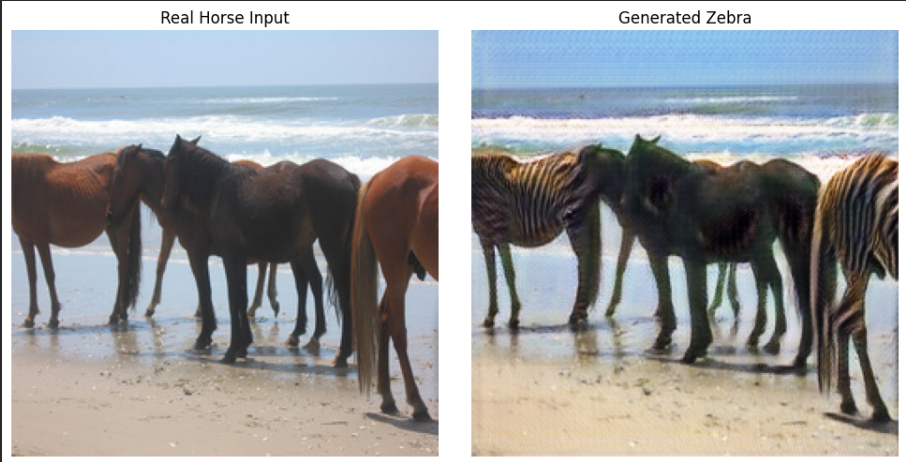